### Кластеризация категорийных данных конкретной предметной области.

Цель работы: проанализировать нуклеотидные последовательности вирусов и выполнить кластеризацию данных с целью выявления схожих генетических структур. 

Автор: студент ПИбд-41, Малафеев ЛС


В первой ячейке у нас будет метод для загрузки, анализа файла. Метод принимает файл, циклом проходится по всем строкам файла и записывает данные в списки. На выходе имеются два списка: identifiers - название и sequences - последовательности этих названий. После открытия файла выполняется небольшая предобработка файла в виде удаления пробелов и символов новой строки, далее идёт по строкам, если встречает ">" то начинает записывать последовательность и название. Если строка последовательностей в файле в несколько строк, то это учитывается для дальнейшей работы. Также убедимся, чтоу каждой последовательности одинаковое количество элементов.

In [ ]:
def load_fasta_like_data(filepath):
    names = []
    sequences = []
    current_seq = ""

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_seq:
                    sequences.append(current_seq)
                    current_seq = ""
                names.append(line[1:])
            else:
                current_seq += line

    if current_seq:
        sequences.append(current_seq)

    return names, sequences


filepath = 'dataset.txt'
sequence_names, sequences = load_fasta_like_data(filepath)
if sequences:
    print(f"загружено последовательностей из файла {len(sequence_names)}")
else: 
    print("ошибка при загрузке последовательностей из файла")

lengths = [len(seq) for seq in sequences]
unique_lengths = set(lengths)
if (len(unique_lengths) > 1):
    print("отредактируйте файл, чтобы последовательности были одной длины")
else:
    print(f"длина каждой последовательности {unique_lengths.pop()}")


загружено последовательностей из файла: 62
длина каждой последовательности: 3537


После загрузки файла нам нужно выполнить подключение библиотеки numpy для приведения списоков к двумерному массиву. Приводим наши списки к двумерному массиву

In [13]:
import numpy as np

sequences_as_arrays = np.array([list(seq) for seq in sequences])
print(f"двумерный массив {sequences_as_arrays.shape} (n_samples, n_features)")


двумерный массив (62, 3537) (n_samples, n_features)


Импортируем из библиотеки функцию pdist, которая будет считать нам попарно расстояния, затем проходимся по всем нуклеотидным последовательностям и достаём оттуда уникальные символы, создаём словарь кодирования. Этот словарь кодирования нам нужен для того, чтоб наши буквы и символы из последовательности перевести в цифры, т.к. метрика Хэммингтона работает с цифрами. Затем мы при помощи функции pdist получаем сжатую версию матрицы (то есть грубо говоря верхний треугольник матрицы), применяем к ней метрику хэммингтона, которая сравнивает между собой последовательности, считает количество различных пар и делит на общее количество пар, вычисляя расстояние

In [ ]:
from scipy.spatial.distance import pdist

all_chars = set()
for seq_array in sequences_as_arrays:
    all_chars.update(seq_array)
unique_chars = sorted(list(all_chars))
print(f"уникальные символы {unique_chars}")

char_to_num = {char: idx for idx, char in enumerate(unique_chars)}
print(f"словарь кодирования {char_to_num}")

vectorized_map = np.vectorize(char_to_num.get)

try:
    sequences_encoded = vectorized_map(sequences_as_arrays)
    print(f"исходная последовательность {sequences[0][:20]}")
    print(f"закодированная последовательность {sequences_encoded[0, :20]}")
except Exception as e:
    print(f"Ошибка при кодировании последовательностей: {e}")
    sequences_encoded = None
    #если ошибка стоп

if sequences_encoded is not None:
    try:
        distance_matrix_condensed = pdist(sequences_encoded, metric='hamming')
        print(f"длина массива метрик {len(distance_matrix_condensed)}")
    except Exception as e:
        print(f"Ошибка при вычислении матрицы расстояний: {e}")

уникальные символы [np.str_('('), np.str_('-'), np.str_('0'), np.str_('A'), np.str_('C'), np.str_('D'), np.str_('G'), np.str_('K'), np.str_('M'), np.str_('N'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('W'), np.str_('Y')]
словарь кодирования {np.str_('('): 0, np.str_('-'): 1, np.str_('0'): 2, np.str_('A'): 3, np.str_('C'): 4, np.str_('D'): 5, np.str_('G'): 6, np.str_('K'): 7, np.str_('M'): 8, np.str_('N'): 9, np.str_('R'): 10, np.str_('S'): 11, np.str_('T'): 12, np.str_('W'): 13, np.str_('Y'): 14}
исходная последовательность ---------ATGAGAGTGAA
закодированная последовательность [ 1  1  1  1  1  1  1  1  1  3 12  6  3  6  3  6 12  6  3  3]
длина массива метрик 1891


Далее импортируем функцию linkage, которая как раз таки принимает сжатую матрицу, сделанную нами выше и тип метода связывания. Т.к. у нас генетика, используем average. На выходе получим матрицу связывания, которая хранит в себе шаги кластеризации. На шаге берутся похожие на себя объекты с наименьшим расстояние между ними и записываются в кластер. Далее идёт построение дендрограммы по этой матрице.

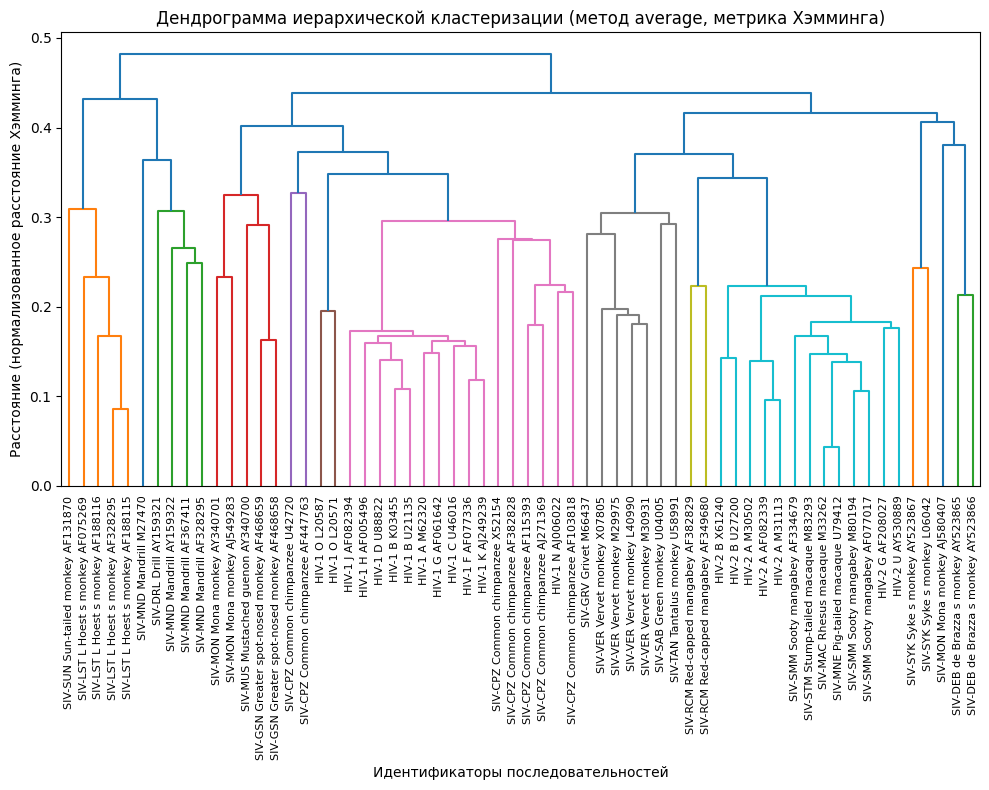

In [41]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

try:
    linkage_matrix = linkage(distance_matrix_condensed, method='average')
except Exception as e:
    print(f"ошибка {e}")
    linkage_matrix = None

if linkage_matrix is not None:
    plt.figure(figsize=(10, 8))
    dendrogram(
        linkage_matrix,
        labels=sequence_names,
        leaf_rotation=90,
        leaf_font_size=8,
        orientation='top'
    )

    plt.title('Дендрограмма иерархической кластеризации (метод average, метрика Хэмминга)')
    plt.xlabel('Идентификаторы последовательностей')
    plt.ylabel('Расстояние (нормализованное расстояние Хэмминга)')
    plt.tight_layout()
    plt.show()
else:
    print("ошибка")


Далее нужно сделать оценку качества. Выполним разбиение на 4, 12 и 20 кластеров. Сделаем это для того, чтоб посмотреть, на сколько кластеров можно разбить наше дерево.

In [53]:

import pandas as pd
from scipy.cluster.hierarchy import fcluster

k_optimal = 12
cluster_labels_optimal = fcluster(linkage_matrix, t=k_optimal, criterion='maxclust')

results_df = pd.DataFrame({
    'ID': sequence_names,
    'Sequence': sequences,
    'Cluster_Label': cluster_labels_optimal
})

for cluster_id in sorted(np.unique(cluster_labels_optimal)):
    cluster_members = results_df[results_df['Cluster_Label'] == cluster_id]
    print(f"\nКластер {cluster_id} ({len(cluster_members)} последовательностей):")
    for idx, row in cluster_members.iterrows():
            print(f"  - {row['ID']}")



Кластер 1 (5 последовательностей):
  - SIV-LST L Hoest s monkey AF328295
  - SIV-LST L Hoest s monkey AF188115
  - SIV-LST L Hoest s monkey AF188116
  - SIV-LST L Hoest s monkey AF075269
  - SIV-SUN Sun-tailed monkey AF131870

Кластер 2 (4 последовательностей):
  - SIV-DRL Drill AY159321
  - SIV-MND Mandrill AY159322
  - SIV-MND Mandrill AF367411
  - SIV-MND Mandrill AF328295

Кластер 3 (1 последовательностей):
  - SIV-MND Mandrill M27470

Кластер 4 (5 последовательностей):
  - SIV-GSN Greater spot-nosed monkey AF468659
  - SIV-GSN Greater spot-nosed monkey AF468658
  - SIV-MON Mona monkey AY340701
  - SIV-MON Mona monkey AJ549283
  - SIV-MUS Mustached guenon AY340700

Кластер 5 (2 последовательностей):
  - SIV-CPZ Common chimpanzee U42720
  - SIV-CPZ Common chimpanzee AF447763

Кластер 6 (2 последовательностей):
  - HIV-1 O L20587
  - HIV-1 O L20571

Кластер 7 (16 последовательностей):
  - HIV-1 B K03455
  - HIV-1 A M62320
  - HIV-1 B U21135
  - HIV-1 C U46016
  - HIV-1 D U88822
  - 

Далее сделаем оценку метрикой качества Silhouette Score. То есть мы посмотрим, как наши объекты похожи на объекты своего кластера в отличие от других кластеров.

In [54]:
from sklearn.metrics import silhouette_score

score_optimal = silhouette_score(sequences_encoded, cluster_labels_optimal, metric='hamming')
print(f"\nSilhouette Score для k={k_optimal}: {score_optimal:.4f}")


Silhouette Score для k=12: 0.3171


По цифрам мы видим значение 0.317. Значение этой метркии варируется от -1 до 1. Как мы видим наша модель неплохо справилась со своей задачей. В качестве тестов наше дерево было разбито ещё на некоторое количество кластеров. Например при 4 кластерах метрика показывала значение 0.309, при количестве кластеров 20 значение было 0.289. Также можно заглянуть в файлик кластеров и последовательностей, там можно заметить, что бибизяньи вирусы схожи между собой даже по названию. Можно сделать вывод о том, что это дерево можно разбить на 12 кластеров.